# Shell-and-Tube Design: Kern Shell Side, U Iteration and Cost Minimisation

`difflow.shell_and_tube` sizes a 1-2N shell-and-tube exchanger. Given the stream data and a duty it

1. assumes `U`, gets the area from `Q = U A F LMTD`,
2. builds a geometry (tube count, shell diameter, baffle spacing),
3. computes the tube-side film coefficient (`heat_transfer.internal_h`, friction from `fluids.friction_factor`) and
   the shell-side one by the **Kern method**, then `U` from `overall_U` with fouling,
4. repeats to a fixed point with `optimistix.fixed_point`, so the whole design is differentiable.

This notebook shows the Kern pieces, the design loop, the rating cross-check with `ShellAndTubeHX`, gradients of
the area with respect to baffle spacing and tube velocity, and a gradient-based **cost minimisation** with the
tube velocity, baffle spacing and number of passes relaxed to continuous values.

**What is and is not validated.** The classic Kern kerosene-crude worked example (Kern 1950; Coulson & Richardson
Vol 6) is **not reproduced**: its inputs and printed answers could not be reproduced from memory with confidence.
Instead each Kern/tube-side equation is checked against a plain-Python hand calculation and the whole loop against an
independent re-implementation (`tests/test_shell_and_tube.py`). The Kern constants (0.36, 0.55; friction
0.576, 0.19), the bundle-diameter constants and the tube tables were **recalled from memory and are not verified
against the books**. **All fluid properties, prices and operating hours below are illustrative placeholders, not
data.**

In [1]:
import jax, jax.numpy as jnp, numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
jax.config.update("jax_enable_x64", True)

from difflow import ShellAndTubeHX, ShellAndTubeHXParams, make_stream
from difflow import shell_and_tube as st
import difflow.economics as econ

## 1. The problem

A hot hydrocarbon (shell side, 5 kg/s, 200 C) is cooled to 100 C by a cooler, more viscous hydrocarbon (tubes,
18 kg/s, 30 C). Properties are **illustrative constants**, passed explicitly (core `SpeciesData` has no liquid
transport properties). Tubes are 19.05 mm OD, 14.83 mm ID on a 1.25 pitch ratio, triangular layout, 4.88 m long
(16 ft); fouling 1e-4 m2K/W on each side.

In [2]:
DO, DI = 0.01905, 0.01483
SHELL = dict(rho=780.0, mu=4.0e-4, k=0.13, Cp=2200.0)    # hot fluid (illustrative)
TUBE  = dict(rho=830.0, mu=2.9e-3, k=0.13, Cp=2050.0)    # cold fluid (illustrative)
hot, cold = {"T": 473.0, "m_dot": 5.0}, {"T": 303.0, "m_dot": 18.0}

def params(**kw):
    base = dict(tube_OD=DO, tube_ID=DI,
                rho_hot=SHELL["rho"], mu_hot=SHELL["mu"], k_hot=SHELL["k"], Cp_hot=SHELL["Cp"],
                rho_cold=TUBE["rho"], mu_cold=TUBE["mu"], k_cold=TUBE["k"], Cp_cold=TUBE["Cp"],
                tube_side="cold", tube_length=4.88, R_fi=1e-4, R_fo=1e-4)
    base.update(kw)
    return st.ShellAndTubeDesignParams(**base)

## 2. The Kern shell side

`kern_shell_side` returns the equivalent diameter `D_e`, the cross-flow area `A_s = (P_t - d_o) D_s l_B / P_t`, the
mass velocity `G_s`, `Re_s` and `h_o` from `Nu = 0.36 Re^0.55 Pr^(1/3) (mu/mu_w)^0.14`;
`kern_shell_pressure_drop` adds the shell `dP`. Closing the baffles raises `h_o` and raises `dP` much faster:

{'De': 0.0135, 'As': 0.018, 'Gs': 277.7778, 'us': 0.3561, 'Re': 9393.3698, 'Pr': 6.7692, 'Nu': 104.2799, 'h_o': 1002.2133}


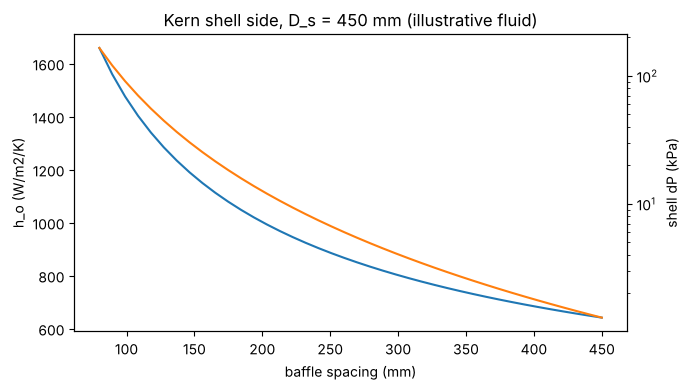

In [3]:
Ds, Pt = 0.45, 1.25 * DO
lB = np.linspace(0.08, 0.45, 40)
ho = [float(st.kern_shell_side(5.0, **SHELL, shell_ID=Ds, tube_OD=DO, pitch=Pt, baffle_spacing=b)["h_o"]) for b in lB]
dp = [float(st.kern_shell_pressure_drop(5.0, SHELL["rho"], SHELL["mu"], Ds, DO, Pt, b, 4.88)["dP"]) for b in lB]
r = st.kern_shell_side(5.0, **SHELL, shell_ID=Ds, tube_OD=DO, pitch=Pt, baffle_spacing=0.2)
print({k: round(float(v), 4) for k, v in r.items()})

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lB * 1e3, ho, label="h_o (W/m2/K)")
ax.set_xlabel("baffle spacing (mm)"); ax.set_ylabel("h_o (W/m2/K)")
ax2 = ax.twinx(); ax2.semilogy(lB * 1e3, np.array(dp) / 1e3, "C1", label="shell dP (kPa)"); ax2.set_ylabel("shell dP (kPa)")
ax.set_title("Kern shell side, D_s = 450 mm (illustrative fluid)")
plt.tight_layout(); plt.show()

## 3. Design by iterating `U`

`ShellAndTubeDesign` takes mass flows and one of `Q`, `T_hot_out`, `T_cold_out`. The result holds the geometry,
`U`, area, `F`, both pressure drops and flags (`F < 0.75`, `dP` above its limit, not converged, laminar tubes).

In [4]:
# tube velocity fixed at 1.5 m/s: the tube count follows from the flow, the tube length from the area
design = st.ShellAndTubeDesign(params(tube_length=None, tube_velocity=1.5, dP_tube_max=7e4, dP_shell_max=7e4))
res = design(hot, cold, T_hot_out=373.0)
keys = ["Q", "U", "area", "F", "LMTD", "T_cold_out", "n_tubes", "tube_length", "bundle_ID", "shell_ID",
        "baffle_spacing", "n_baffles", "tube_velocity", "h_i", "h_o", "Re_tube", "Re_shell", "dP_tube", "dP_shell",
        "U_residual"]
for k in keys:
    print(f"{k:>15s} = {float(res[k]):.6g}")
print("converged:", bool(res["converged"]), "| F too low:", bool(res["F_too_low"]),
      "| dP exceeded:", bool(res["dP_tube_exceeded"]), bool(res["dP_shell_exceeded"]))

              Q = 1.1e+06
              U = 391.902
           area = 29.297
              F = 0.947964
           LMTD = 101.065
     T_cold_out = 332.81
        n_tubes = 167.402
    tube_length = 2.92427
      bundle_ID = 0.363977
       shell_ID = 0.413977
 baffle_spacing = 0.165591
      n_baffles = 16.6596
  tube_velocity = 1.5
            h_i = 910.287
            h_o = 1164.09
        Re_tube = 6366.67
       Re_shell = 12332.5
        dP_tube = 21674.4
       dP_shell = 13688.6
     U_residual = 7.76389e-11
converged: True | F too low: False | dP exceeded: False False


The same problem with the tube **length** fixed at 4.88 m instead (the tube count then follows from the area).
The iteration converges to the same `U` from any typical starting value. **The fixed point is not unique** with a
fixed tube length: more area means more tubes, slower tube flow and a lower `h_i`, a positive feedback. A very low guess
settles on a second, large-area laminar solution, which the result flags (`tube_laminar`) and warns about; fixing the
tube velocity (section 6) removes the feedback.

In [5]:
import warnings
for U0 in (150.0, 500.0, 2000.0, 5000.0, 50.0):
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        r = st.ShellAndTubeDesign(params(U_guess=U0))(hot, cold, T_hot_out=373.0, warn=True)
    print(f"U_guess {U0:6.0f} -> U = {float(r['U']):8.2f}  A = {float(r['area']):7.2f} m2  Re_tube = {float(r['Re_tube']):8.0f}"
          + ("   <- laminar, large-area branch (warned)" if len(w) else ""))

U_guess    150 -> U =   861.72  A =   13.32 m2  Re_tube =    23362


U_guess    500 -> U =   861.72  A =   13.32 m2  Re_tube =    23362


U_guess   2000 -> U =   861.72  A =   13.32 m2  Re_tube =    23362


U_guess   5000 -> U =   861.72  A =   13.32 m2  Re_tube =    23362


U_guess     50 -> U =    54.39  A =  211.11 m2  Re_tube =     1474   <- laminar, large-area branch (warned)


## 4. Rating cross-check

`ShellAndTubeHX` rates a 1-2N exchanger from `UA`. Fed the design's `U * A` it must return the design duty and outlet
temperatures. (Doing this check exposed two bugs in the rating path, fixed in the same change: the Bowman F factor
ignored its own formula for `|R-1| > 0.075`, and `ShellAndTubeHX` computed `Q = F Q_cc` instead of
`Q = UA F LMTD`. See the changelog.) `rate` re-rates any given geometry with the correlations.

In [6]:
MW = 0.018      # arbitrary: only C = m Cp matters
hx = ShellAndTubeHX(ShellAndTubeHXParams(UA=float(res["U"] * res["area"]),
                                         Cp_hot=SHELL["Cp"] * MW, Cp_cold=TUBE["Cp"] * MW))
ho_, co_, info = hx(make_stream({"A": 5.0 / MW}, 473.0, 101325.0), make_stream({"A": 18.0 / MW}, 303.0, 101325.0))
print(f"design : Q = {float(res['Q']):.1f} W, T_hot_out = 373.000 K, T_cold_out = {float(res['T_cold_out']):.4f} K, F = {float(res['F']):.5f}")
print(f"rating : Q = {float(info['Q']):.1f} W, T_hot_out = {float(ho_['T']):.3f} K, T_cold_out = {float(co_['T']):.4f} K, F = {float(info['F_correction']):.5f}")
rt = design.rate(hot, cold, res["n_tubes"], res["tube_length"], res["shell_ID"], res["baffle_spacing"])
print(f"rate() : Q = {float(rt['Q']):.1f} W (geometry -> correlations -> effectiveness)")

design : Q = 1100000.0 W, T_hot_out = 373.000 K, T_cold_out = 332.8103 K, F = 0.94796
rating : Q = 1100000.0 W, T_hot_out = 373.000 K, T_cold_out = 332.8103 K, F = 0.94796
rate() : Q = 1100000.0 W (geometry -> correlations -> effectiveness)


## 5. Gradients through the fixed point

With the tube velocity fixed the tube count follows from the flow and the tube length from the area. The area is
then a differentiable function of baffle spacing and tube velocity (implicit-function-theorem gradient of
`optx.fixed_point`):

In [7]:
vd = st.ShellAndTubeDesign(params(tube_length=None, tube_velocity=1.2, baffle_spacing=0.25, tol=1e-13))
area = lambda lB, v: vd(hot, cold, T_hot_out=373.0, baffle_spacing=lB, tube_velocity=v, warn=False)["area"]
g = jax.grad(area, argnums=(0, 1))(0.25, 1.2)
h = 1e-5
fd = ((area(0.25 + h, 1.2) - area(0.25 - h, 1.2)) / (2 * h), (area(0.25, 1.2 + h) - area(0.25, 1.2 - h)) / (2 * h))
print(f"A = {float(area(0.25, 1.2)):.3f} m2")
print(f"dA/dl_B : jax.grad {float(g[0]):+.5f}  finite difference {float(fd[0]):+.5f}  m2 per m")
print(f"dA/dv   : jax.grad {float(g[1]):+.5f}  finite difference {float(fd[1]):+.5f}  m2 per m/s")

A = 36.903 m2
dA/dl_B : jax.grad +28.58865  finite difference +28.58865  m2 per m
dA/dv   : jax.grad -21.68420  finite difference -21.68420  m2 per m/s


## 6. Gradient-based cost minimisation

Minimise annualised capital (`heat_exchanger_cost(area)` times a capital charge) plus pumping cost, over the
**continuous** tube velocity, baffle spacing and number of tube passes, subject to `dP` limits on both sides and
`Re_tube >= 1e4` (keeps the design out of the unphysical interpolated transition range).

**Every price, the annuity factor, the operating hours, the pump efficiency and the `dP` limits are illustrative
placeholders.** `heat_exchanger_cost` is the library's power-law correlation (`11000 + 340 A^0.6`, 2019 dollars
escalated), not a quote. SLSQP uses `jax.grad`/`jax.jacobian` of the design as exact gradients.

In [8]:
ANN, HOURS, PRICE_KWH, ETA, DPMAX = 0.20, 8000.0, 0.10, 0.60, 7.0e4    # all illustrative
design_v = st.ShellAndTubeDesign(params(tube_length=None, tube_velocity=1.0, tol=1e-12, U_guess=800.0))

def solve(x):
    v, lb, npass = jnp.exp(x[0]), jnp.exp(x[1]), x[2]
    return design_v(hot, cold, T_hot_out=373.0, tube_velocity=v, baffle_spacing=lb, n_tube_passes=npass, warn=False)

def cost_terms(r):
    capital = ANN * econ.heat_exchanger_cost(r["area"])
    power = (cold["m_dot"] / TUBE["rho"] * r["dP_tube"] + hot["m_dot"] / SHELL["rho"] * r["dP_shell"]) / ETA   # W
    return capital, power / 1e3 * HOURS * PRICE_KWH

total = lambda x: sum(cost_terms(solve(x)))
cons = lambda x: (lambda r: jnp.array([DPMAX - r["dP_tube"], DPMAX - r["dP_shell"], r["Re_tube"] - 1e4]) / jnp.array([1e4, 1e4, 1e3]))(solve(x))
vg, cj = jax.jit(jax.value_and_grad(total)), jax.jit(jax.jacobian(cons))
cf = jax.jit(cons)

x0 = np.array([np.log(1.0), np.log(0.25), 2.0])
sol = minimize(lambda x: tuple(np.asarray(a) for a in vg(x)), x0, jac=True, method="SLSQP",
               bounds=[(np.log(0.3), np.log(3.0)), (np.log(0.05), np.log(1.0)), (1.0, 8.0)],
               constraints=[{"type": "ineq", "fun": lambda x: np.asarray(cf(x)), "jac": lambda x: np.asarray(cj(x))}])
print(sol.message, "| iterations:", sol.nit)
for name, x in (("start", x0), ("optimum", sol.x)):
    r = solve(x); cap, pump = cost_terms(r)
    print(f"{name:8s} v = {np.exp(x[0]):.3f} m/s  l_B = {np.exp(x[1])*1e3:6.1f} mm  passes = {x[2]:.2f}  "
          f"A = {float(r['area']):6.2f} m2  L = {float(r['tube_length']):.2f} m  Ds = {float(r['shell_ID']):.3f} m  "
          f"dP_t = {float(r['dP_tube'])/1e3:5.1f} kPa  dP_s = {float(r['dP_shell'])/1e3:5.1f} kPa  "
          f"Re_t = {float(r['Re_tube']):.0f}  cost = {float(cap + pump):,.0f} $/yr (capital {float(cap):,.0f} + pumping {float(pump):,.0f})")

Optimization terminated successfully | iterations: 10


start    v = 1.000 m/s  l_B =  250.0 mm  passes = 2.00  A =  42.25 m2  L = 2.81 m  Ds = 0.487 m  dP_t =  10.0 kPa  dP_s =   3.6 kPa  Re_t = 4244  cost = 4,157 $/yr (capital 3,837 + pumping 320)


optimum  v = 2.356 m/s  l_B =  249.8 mm  passes = 1.00  A =  22.91 m2  L = 7.18 m  Ds = 0.258 m  dP_t =  48.6 kPa  dP_s =  15.5 kPa  Re_t = 10000  cost = 5,107 $/yr (capital 3,570 + pumping 1,537)


The starting point violates the `Re_tube >= 1e4` constraint (Re about 4200), so its lower cost is not comparable. The
optimum sits **on the `Re_tube = 1e4` constraint with the passes at their lower bound of 1**: with the library's shallow
capital correlation (`A^0.6` over a fixed term) and these placeholder prices the pumping cost is small, so the
economics ask for as much area reduction as the constraints allow. That is a statement about the placeholder economics, not
about heat exchangers. A velocity scan at the optimal baffle spacing and passes shows the trade (capital falls, pumping
rises) and that the gradient-based optimum is the scan minimum among feasible points:

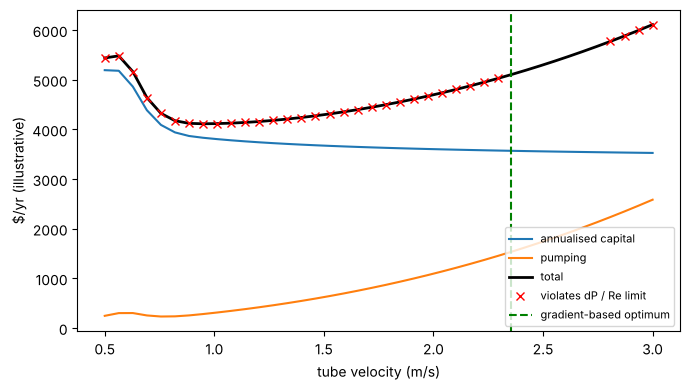

scan minimum among feasible points: v = 2.36 m/s; gradient-based optimum v = 2.356 m/s


In [9]:
vs = np.linspace(0.5, 3.0, 40)
xs = [np.array([np.log(v), sol.x[1], sol.x[2]]) for v in vs]
caps, pumps = zip(*[(float(a), float(b)) for a, b in (cost_terms(solve(x)) for x in xs)])
feas = [bool(np.all(np.asarray(cf(x)) >= 0)) for x in xs]
tot = np.array(caps) + np.array(pumps)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(vs, caps, label="annualised capital"); ax.plot(vs, pumps, label="pumping")
ax.plot(vs, tot, "k", lw=2, label="total")
ax.plot(vs[~np.array(feas)], tot[~np.array(feas)], "rx", label="violates dP / Re limit")
ax.axvline(np.exp(sol.x[0]), color="g", ls="--", label="gradient-based optimum")
ax.set_xlabel("tube velocity (m/s)"); ax.set_ylabel("$/yr (illustrative)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()
best = vs[np.argmin(np.where(feas, tot, np.inf))]
print(f"scan minimum among feasible points: v = {best:.2f} m/s; gradient-based optimum v = {np.exp(sol.x[0]):.3f} m/s")

### Rounding and re-rating

Tube count, passes and baffle count are real numbers in the optimisation. To build the exchanger, `round_design`
rounds the tube count up, the passes to the nearest standard even count, the baffle spacing down and the shell
diameter up to a standard step, and `rate` re-rates that geometry (velocities, `h_i`, `h_o` and both `dP` all change):

In [10]:
opt = solve(sol.x)
g = st.round_design(opt)
print({k: round(v, 4) for k, v in g.items()})
dsg = st.ShellAndTubeDesign(params(tube_length=None, tube_velocity=1.0))
rr = dsg.rate(hot, cold, **g)
print(f"re-rated: Q = {float(rr['Q'])/1e3:.1f} kW (target {float(opt['Q'])/1e3:.1f}), T_hot_out = {float(rr['T_hot_out']):.2f} K, "
      f"area = {float(rr['area']):.2f} m2 (design {float(opt['area']):.2f}), dP_t = {float(rr['dP_tube'])/1e3:.1f} kPa, "
      f"dP_s = {float(rr['dP_shell'])/1e3:.1f} kPa")

{'n_tubes': 54.0, 'n_tube_passes': 1.0, 'tube_length': 7.1825, 'shell_ID': 0.2667, 'baffle_spacing': 0.225}
re-rated: Q = 1113.0 kW (target 1100.0), T_hot_out = 371.82 K, area = 23.21 m2 (design 22.91), dP_t = 47.4 kPa, dP_s = 20.3 kPa


## 7. Condensing or boiling shell side

A phase-changing side is isothermal (`hot_isothermal=True`: `F = 1`) and its film coefficient comes from outside the Kern
method: a number, or a function of the geometry such as `nusselt_film_condensation` for a horizontal tube bank. Shell
`dP` is not modelled in this mode. Steam at 100 C (illustrative properties) condensing on the outside of a tube bundle
heating the cold oil:

In [11]:
from difflow import heat_transfer as ht
def shell_h(g):
    n_col = jnp.sqrt(g["n_tubes"])          # tubes per vertical row: a crude placeholder
    return ht.nusselt_film_condensation(k_l=0.68, rho_l=958.0, rho_v=0.6, mu_l=2.8e-4, h_fg=2.257e6,
                                        Cp_l=4216.0, dT=10.0, L=g["tube_OD"], n_tubes=n_col)
cond = st.ShellAndTubeDesign(params(hot_isothermal=True, shell_h=shell_h, tube_length=None, tube_velocity=1.5, R_fo=1e-4))
rc = cond({"T": 373.15, "m_dot": 1.0}, cold, Q=1.0e6)
print(f"h_o = {float(rc['h_o']):.0f} W/m2/K, U = {float(rc['U']):.0f}, A = {float(rc['area']):.2f} m2, "
      f"Nt = {float(rc['n_tubes']):.0f}, T_cold_out = {float(rc['T_cold_out']):.1f} K, F = {float(rc['F'])}")
print("dA/dQ =", float(jax.grad(lambda Q: cond({"T": 373.15, "m_dot": 1.0}, cold, Q=Q, warn=False)["area"])(1.0e6)), "m2/W")

h_o = 7172 W/m2/K, U = 546, A = 33.01 m2, Nt = 167, T_cold_out = 330.1 K, F = 1.0


dA/dQ = 4.2556690612549905e-05 m2/W
